# Rendering


In [31]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcad.render import Material, raymarch, render_marching_cubes, render_raymarched
from jaxcad.sdf.boolean import Difference, Intersection, Union
from jaxcad.sdf.primitives import Box, Capsule, RoundBox, Sphere, Torus
from jaxcad.sdf.transforms import Translate

In [32]:
# ── Colour palette & scene defaults ──────────────────────────────────────────
# Named materials and defaults used consistently across every example.
M = {
    "blue": Material(color=[0.22, 0.50, 0.95], roughness=0.35),
    "red": Material(color=[0.93, 0.26, 0.22], roughness=0.70),
    "green": Material(color=[0.05, 0.72, 0.50], roughness=0.50),
    "gold": Material(color=[0.97, 0.76, 0.12], roughness=0.20, metallic=1.0),
    "purple": Material(color=[0.55, 0.25, 0.95], roughness=0.50),
    "white": Material(color=[0.84, 0.84, 0.82], roughness=0.95),
    "glass": Material(color=[0.92, 0.97, 1.0], roughness=0.05, opacity=0.1, ior=1.5),
}

bg = jnp.array([0.08, 0.10, 0.18])  # default scene background

## 1. Primitives side-by-side

Each primitive rendered from the same camera position.

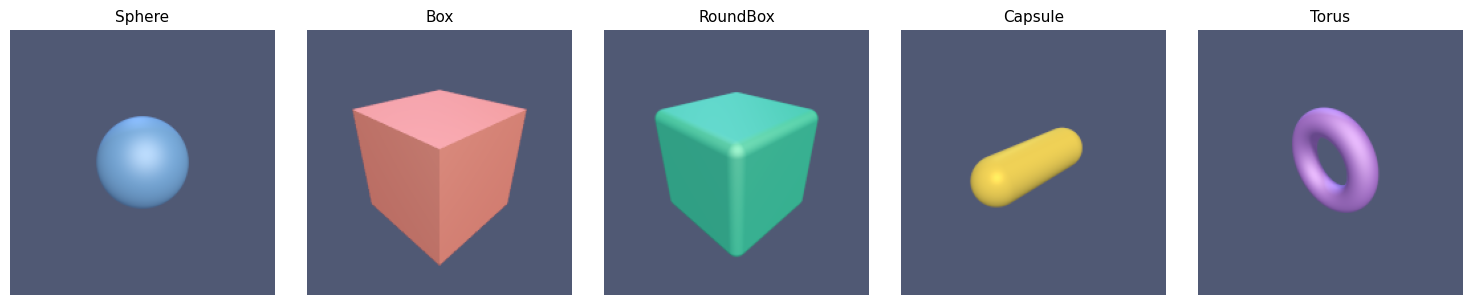

In [33]:
primitives = {
    "Sphere": Sphere(radius=1.0, material=M["blue"]),
    "Box": Box(size=[1.2, 1.2, 1.2], material=M["red"]),
    "RoundBox": RoundBox(size=[1.0, 1.0, 1.0], radius=0.2, material=M["green"]),
    "Capsule": Capsule(radius=0.5, height=1.0, material=M["gold"]),
    "Torus": Torus(major_radius=0.9, minor_radius=0.3, material=M["purple"]),
}

fig, axes = plt.subplots(1, len(primitives), figsize=(3 * len(primitives), 3))

cam = jnp.array([3.0, 2.5, 3.0])
light_dirs = jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]])
light_colors = jnp.array([[1.0, 0.92, 0.75], [0.25, 0.35, 0.65]])

for ax, (name, sdf) in zip(axes, primitives.items()):
    img = raymarch(
        sdf,
        camera_pos=cam,
        light_dirs=light_dirs,
        light_colors=light_colors,
        background_color=bg,
        resolution=(200, 200),
        aa_samples=2,
    )
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

## 2. Boolean operations

Union, intersection, and difference of two overlapping shapes.

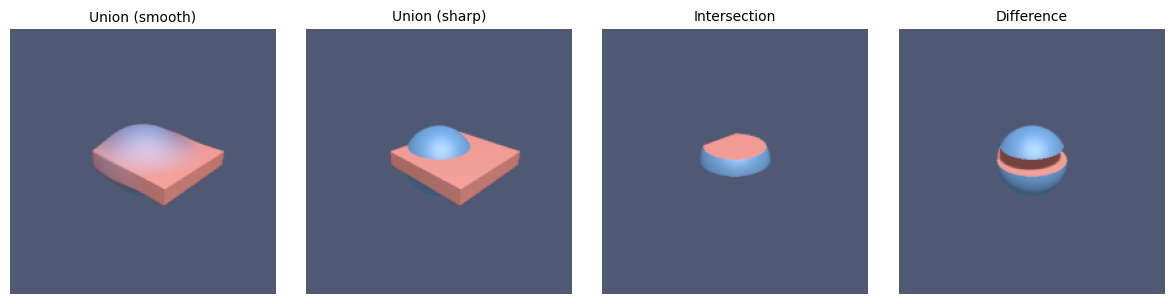

In [34]:
s = Sphere(radius=1.0, material=M["blue"])
b = Translate(Box(size=[1.2, 0.2, 1.2], material=M["red"]), offset=jnp.array([0.6, 0.3, 0.0]))

scenes = {
    "Union (smooth)": Union((s, b), smoothness=0.2),
    "Union (sharp)": Union((s, b), smoothness=0.0),
    "Intersection": Intersection((s, b), smoothness=0.0),
    "Difference": Difference((s, b), smoothness=0.0),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
cam = jnp.array([4.0, 3.0, 4.0])

for ax, (name, scene) in zip(axes, scenes.items()):
    img = raymarch(scene, camera_pos=cam, background_color=bg, resolution=(200, 200), aa_samples=2)
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

## 3. Shadow hardness

The `shadow_hardness` parameter controls shadow edge sharpness.  
Low values give soft penumbra; high values give hard edges.

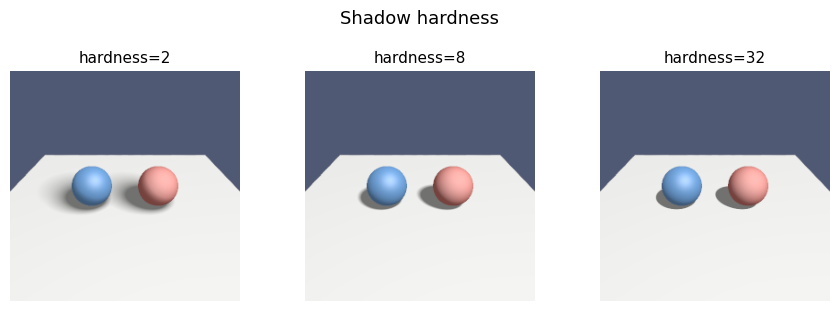

In [35]:
scene = Union(
    (
        Translate(Sphere(radius=0.6, material=M["blue"]), offset=jnp.array([-1.0, 0.0, 0.0])),
        Translate(Sphere(radius=0.6, material=M["red"]), offset=jnp.array([1.0, 0.0, 0.0])),
        Translate(
            Box(size=[4.0, 0.1, 4.0], material=M["white"]), offset=jnp.array([0.0, -0.7, 0.0])
        ),
    ),
    smoothness=0.0,
)

hardness_values = [2.0, 8.0, 32.0]
labels = [f"hardness={h:.0f}" for h in hardness_values]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
cam = jnp.array([0.0, 3.0, 5.0])
light = jnp.array([2.0, 4.0, 2.0])

for ax, h, label in zip(axes, hardness_values, labels):
    img = raymarch(
        scene,
        camera_pos=cam,
        light_dirs=light,
        background_color=bg,
        resolution=(250, 250),
        shadow_hardness=h,
        aa_samples=2,
    )
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Shadow hardness", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Complex scene

A cluster of spheres smoothly blended together — the colour gradients at the joints are what make this visually striking.

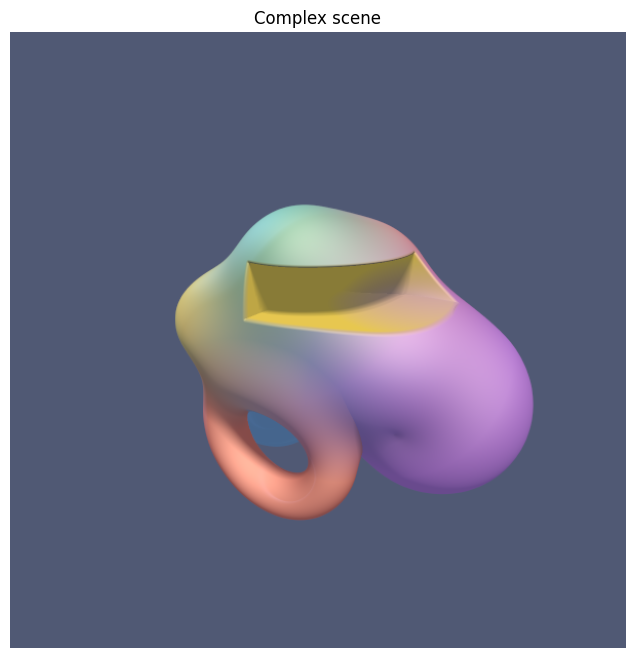

In [66]:
blob = Union(
    (
        Sphere(radius=0.80, material=M["blue"]),
        Translate(Sphere(radius=0.70, material=M["purple"]), offset=jnp.array([1.2, 0.2, 0.0])),
        Translate(Sphere(radius=0.60, material=M["red"]), offset=jnp.array([0.5, 0.9, -0.7])),
        Translate(Sphere(radius=0.50, material=M["gold"]), offset=jnp.array([-1.0, 0.4, 0.5])),
        Translate(Sphere(radius=0.40, material=M["green"]), offset=jnp.array([0.1, 1.3, 0.3])),
    ),
    smoothness=0.30,
)

blob = Difference(
    (
        blob,
        Translate(Box(size=[1.0, 0.3, 1.0], material=M["gold"]), offset=jnp.array([0.9, 1.0, 0.4])),
    ),
    smoothness=0.01,
)

rects = Union(
    (
        Translate(
            Torus(major_radius=0.9, minor_radius=0.3, material=M["red"]),
            offset=jnp.array([-0.2, -1.1, 0.4]),
        ),
        Translate(
            Torus(major_radius=0.3, minor_radius=0.9, material=M["purple"]),
            offset=jnp.array([1.5, -0.5, -0.6]),
        ),
        Translate(
            Torus(major_radius=0.9, minor_radius=0.3, material=M["blue"]),
            offset=jnp.array([-1.2, -0.8, -0.5]),
        ),
    ),
    smoothness=0.0,
)

scene = Union((blob, rects), smoothness=0.15)

render_raymarched(
    scene,
    camera_pos=jnp.array([3.5, 2.5, 5.0]),
    look_at=jnp.array([0.2, 0.2, 0.0]),
    light_dirs=jnp.array([[1.5, 3.0, 1.5], [-2.0, 1.0, -0.5]]),
    light_colors=jnp.array([[1.0, 0.88, 0.65], [0.30, 0.45, 0.80]]),
    background_color=bg,
    resolution=(600, 600),
    shadow_hardness=8.0,
    aa_samples=2,
    title="Complex scene",
)
plt.show()

## 5. Raymarcher vs marching cubes

Both renderers on the same scene for comparison.

In [ ]:
scene = Union(
    (
        Translate(Sphere(radius=0.8, material=M["blue"]), offset=jnp.array([-0.9, 0.0, 0.0])),
        Translate(Sphere(radius=0.8, material=M["red"]), offset=jnp.array([0.9, 0.0, 0.0])),
    ),
    smoothness=0.3,
)

fig = plt.figure(figsize=(10, 4))

# Raymarcher
ax1 = fig.add_subplot(121)
render_raymarched(
    scene,
    camera_pos=jnp.array([3.0, 2.0, 4.0]),
    light_dirs=jnp.array([[1.5, 2.0, 1.5], [-1.0, 0.4, -0.5]]),
    light_colors=jnp.array([[1.0, 0.90, 0.70], [0.20, 0.30, 0.60]]),
    background_color=bg,
    resolution=(350, 350),
    aa_samples=2,
    ax=ax1,
    title="Sphere tracing",
)

# Marching cubes
ax2 = fig.add_subplot(122, projection="3d")
render_marching_cubes(
    scene,
    bounds=(-2.5, -2.5, -2.5),
    size=(5, 5, 5),
    resolution=60,
    color="#3A82F5",
    alpha=0.85,
    ax=ax2,
    title="Marching cubes",
)
ax2.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

## 6. Glass Refraction

When `ior > 1.0`, rays obey Snell's law at entry and exit:

1. Primary ray hits the front face → bends **into** the material.
2. Interior trace finds the back face (using `−sdf` as the distance field).
3. Ray bends back **into air** and continues through the scene.

The **Fresnel effect** (Schlick approximation) brightens edges at grazing angles.  
IOR sweep — air → water → glass → diamond.

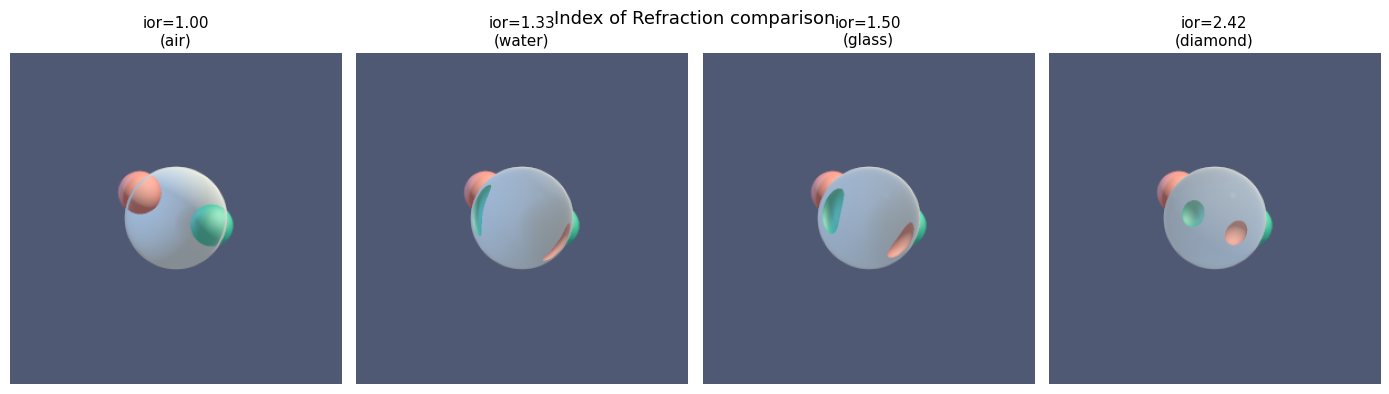

In [67]:
red_ball = Translate(Sphere(radius=0.65, material=M["red"]), offset=jnp.array([-1.1, 0.5, -3.0]))
green_ball = Translate(
    Sphere(radius=0.65, material=M["green"]), offset=jnp.array([1.1, -0.5, -3.0])
)

cam_glass = jnp.array([0.0, 0.5, 5.5])
look_glass = jnp.array([0.0, 0.0, 0.0])
lights_g = jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]])
lcolors_g = jnp.array([[1.0, 0.90, 0.70], [0.20, 0.35, 0.60]])


def render_glass(ior, res=300):
    scene = Union(
        (
            Sphere(
                radius=1.0,
                material=Material(color=[0.92, 0.97, 1.0], roughness=0.05, opacity=0.04, ior=ior),
            ),
            red_ball,
            green_ball,
        ),
        smoothness=0.0,
    )
    return raymarch(
        scene,
        camera_pos=cam_glass,
        look_at=look_glass,
        light_dirs=lights_g,
        light_colors=lcolors_g,
        resolution=(res, res),
        background_color=bg,
        refract_steps=48,
        max_steps=80,
        aa_samples=2,
        ambient=0.04,
    )


ior_cases = [
    (1.00, "ior=1.00\n(air)"),
    (1.33, "ior=1.33\n(water)"),
    (1.50, "ior=1.50\n(glass)"),
    (2.42, "ior=2.42\n(diamond)"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (ior, label) in zip(axes, ior_cases):
    ax.imshow(render_glass(ior), vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Index of Refraction comparison", fontsize=13)
plt.tight_layout()
plt.show()